# Inversions for tensile dislocation models with okapy and SciPy

A simple inversion making use of the Powell algorithm built into the scipy.optimize.minimize function, the Okada model in okapy and our downsampled data in 'okinv' format to try to obtain a best-fitting model of an dike.

## Set it up! 

Let's start with some dependencies:

In [14]:
from okapy import rect_tensile_fault, los_penalty_tensile
from math import sin, cos, tan, radians, floor
from matplotlib import cm, colors
from scipy.optimize import minimize, Bounds
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import time

## Defining the data, model parameters and elastic constants

Load in the downsampled interfrogram data:

In [15]:
#data = np.loadtxt('hawaii_crop.okinv', delimiter=' ') # or wherever the file is on your system!
#data[:,0]*=1000  # convert x coord from km to m
#data[:,1]*=1000  # convert y coord from km to m

# let's try to make a list!
data = list()
datanames = list()

# load in a data file (need to copy this block for each data file)
# add the full path to the data file here:
indata = np.loadtxt('./hawaii_crop.okinv', 
                    usecols=(0,1,2,3,4,5))
indata[:,0]*=1000  # convert x coord from km to m
indata[:,1]*=1000  # convert y coord from km to m
data.append(indata)
dataname = 'Hawaii descending'
datanames.append(dataname)

# load in a data file (need to copy this block for each data file)
# add the full path to the data file here:
#indata = np.loadtxt('./pishan_dsc_cropped.okinv', 
#                    usecols=(0,1,2,3,4,5))
#indata[:,0]*=1000  # convert x coord from km to m
#indata[:,1]*=1000  # convert y coord from km to m
#data.append(indata)
#dataname = 'Hawaii ascending'
#datanames.append(dataname)

Let's specify some parameters for our models: starting guesses and uncertainties

In [16]:
# for each quantity, starting guess is the first value, sigma the second
strike = [60, 10]        # in degrees
dip = [85, 10]           # in degrees
opening = [2, 0.5]          # in m
xc = [275000, 5000]        # x coord of dislocation centroid, in m 
yc = [2145000, 5000]       # y coord of dislocation centroid, in m
zc = [2000, 1000]            # z coord of dislocation centroid, in n
as_length = [5000, 2000]     # along-strike dislocation length, in m
dd_width = [4000, 2000]      # down-dip dislocation width, in m

fpstart = np.array([strike[0], dip[0], opening[0], xc[0], yc[0], zc[0], as_length[0], dd_width[0]])
fpsigma = np.array([strike[1], dip[1], opening[1], xc[1], yc[1], zc[1], as_length[1], dd_width[1]])

# let's calculate some 2-sigma bounds on these starting values:
fplowb = fpstart-2*fpsigma
fphighb = fpstart+2*fpsigma

# find a random starting model (assume flat pdf between lower and upper bounds)
fparams_restart = fpstart + np.multiply(((np.random.random_sample(8)*4)-2),fpsigma)
    
# and output the starting model    
print("example starting model parameters:")
print('  strike:',fparams_restart[0],'dip:',fparams_restart[1],'opening:',fparams_restart[2])
print('  xc:',fparams_restart[3],'yc:',fparams_restart[4],'zc:',fparams_restart[5])
print('  length:',fparams_restart[6],'width:',fparams_restart[7])

example starting model parameters:
  strike: 57.787661391082814 dip: 94.42818516583993 opening: 1.3633952159668228
  xc: 273949.16796394024 yc: 2142208.977997034 zc: 1612.0608419588254
  length: 7650.503032479756 width: 4123.660023914889


Finally, let's define some elastic parameters, using some standard values:

In [17]:
eparams = np.array([30e9, 30e9])  # 1st and 2nd Lame elastic parameters; try 30 GPa for both

## Parallelized looping to find the global minimum

This makes use of the `joblib` routines for embarrassingly parallel (i.e. completely independent) problems. I think I've got it working properly!

In [18]:
nrestarts=100   # how many restarts do you want?
njobs=8         # how many parallel processes?

# set a timer
t1=time.time()

# we need a function to use in the parallel loop
def powell_optimize(i,fpstart,fpsigma,fplowb,fphighb,eparams,data):

    # find a random starting model (assume flat pdf between lower and upper bounds)
    fparams_restart = fpstart + np.multiply(((np.random.rand(8)*4)-2),fpsigma)

    # sanity check of depths (make sure whole intrusion is below ground)
    mindepth=fparams_restart[5]-(fparams_restart[7]/2)*np.sin(np.radians(fparams_restart[1]))
    
    if mindepth<0:
        fparams_restart[5]=(fparams_restart[7]/2)*np.sin(np.radians(fparams_restart[1]))

        
    # set inversion bounds
    fpbounds = Bounds(fplowb,fphighb)
        
    # and run the Powell algorithm minimizer! 
    results = minimize(los_penalty_tensile, fparams_restart, args=(eparams, data),  method='Powell', 
                   bounds=fpbounds)
    
    #print("restart {0:d}, penalty: {1:f}".format(i,results.fun))
    
    return results.fun, results.x
    

# and we can run the parallel loop now... easy when you know how
results = Parallel(n_jobs=njobs)(delayed(powell_optimize)(i,fpstart,fpsigma,fplowb,fphighb,eparams,data)
                                 for i in range(nrestarts))

# done? check the time
t2=time.time()


# with the inversion done, let's parse the results (which are a list of lists)
penalties=[item[0] for item in results]
fparams=[item[1] for item in results]

# what is the best penalty?
best_penalty=np.min(penalties)

# find the index for the best penalty
idx=[i for i in range(len(penalties)) if penalties[i]==best_penalty]

# and the best parameters are...
best_fparams=fparams[idx[0]]

print('{0:d} restarts completed in {1:f} seconds'.format(nrestarts,t2-t1))
print('best penalty: {0:f}'.format(best_penalty))
print(' ')
print("final fault parameters:")
print('  strike:',best_fparams[0],' dip:',best_fparams[1],' opening:',best_fparams[2])
print('  xc:',best_fparams[3],' yc:',best_fparams[4],' zc:',best_fparams[5])
print('  length:',best_fparams[6],' width:',best_fparams[7])


100 restarts completed in 24.461712 seconds
best penalty: 0.119484
 
final fault parameters:
  strike: 52.83640985154881  dip: 68.14202218077142  opening: 2.001067823756407
  xc: 275732.56179570226  yc: 2143494.932390857  zc: 1696.1533251163198
  length: 3481.5610004246637  width: 2163.1333561204365


## It is good practice to plot your results and residuals

We can use the routines we developed in earlier notebooks to do this!

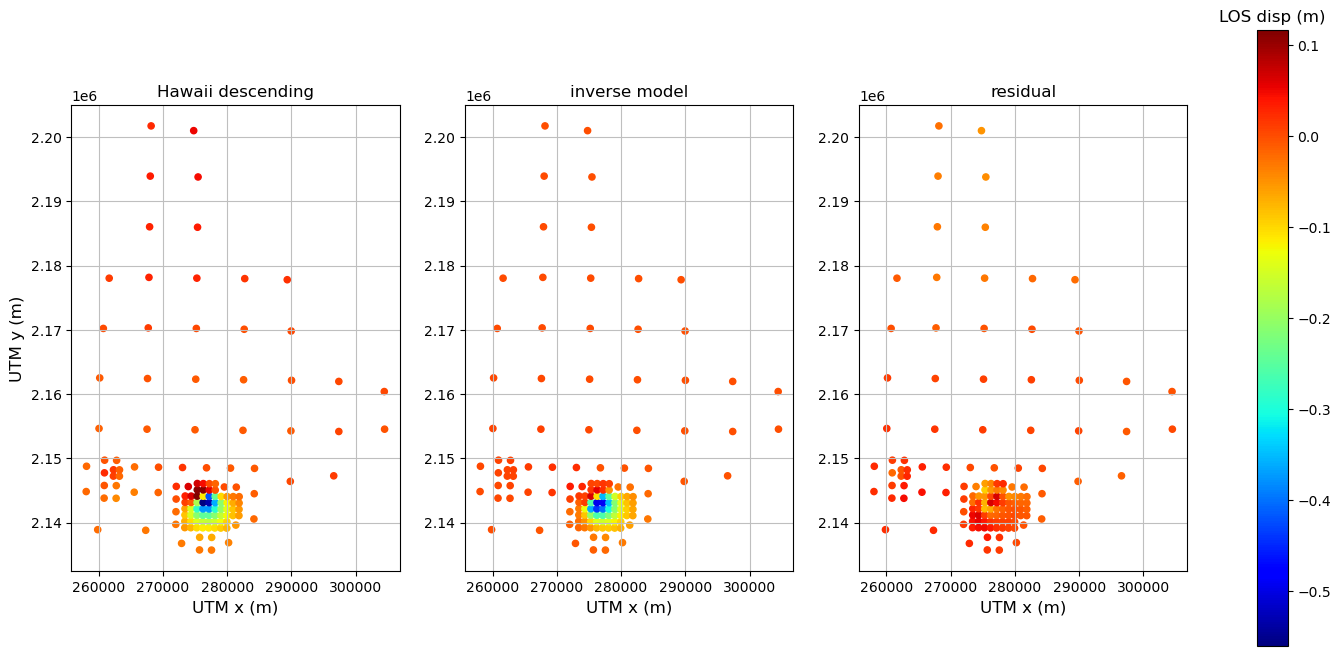

In [19]:
# Plot the 'best' model

# do we want the best fault plane
plot_fault=False

# calculate the displacements
model_los_disps = rect_tensile_fault(best_fparams, eparams, data)

# extract fault location for plotting

#top of the fault
linex=[best_fparams[3]+(best_fparams[6]/2)*np.sin(np.radians(best_fparams[0])),
       best_fparams[3]-(best_fparams[6]/2)*np.sin(np.radians(best_fparams[0]))]
liney=[best_fparams[4]+(best_fparams[6]/2)*np.cos(np.radians(best_fparams[0])),
       best_fparams[4]-(best_fparams[6]/2)*np.cos(np.radians(best_fparams[0]))]

topdepth=fparams_restart[5]-(fparams_restart[7]/2)*np.sin(np.radians(fparams_restart[1]))
botdepth=fparams_restart[5]+(fparams_restart[7]/2)*np.sin(np.radians(fparams_restart[1]))

#top and bottom of the fault factors
r1=topdepth/np.tan(np.radians(best_fparams[1]))
r2=botdepth/np.tan(np.radians(best_fparams[1]))

#arrays for the fault shape
faultx=[linex[0]+r1*np.sin(np.radians(best_fparams[0]+90)), linex[0]+r2*np.sin(np.radians(best_fparams[0]+90)), 
        linex[1]+r2*np.sin(np.radians(best_fparams[0]+90)), linex[1]+r1*np.sin(np.radians(best_fparams[0]+90))]

faulty=[liney[0]+r1*np.cos(np.radians(best_fparams[0]+90)), liney[0]+r2*np.cos(np.radians(best_fparams[0]+90)), 
        liney[1]+r2*np.cos(np.radians(best_fparams[0]+90)), liney[1]+r1*np.cos(np.radians(best_fparams[0]+90))]

# parse the input data
ndset = len(data)

# loop through your datasets
for i in range(ndset):

    # grab yer data
    dataset=data[i]
    
    # calculate the mean residual
    zero_shift = np.mean(dataset[:,2]-model_los_disps[i])
    
    # calculate the residual without nuisances...
    shifted_data = dataset[:,2]-zero_shift
    residual_los_disps = model_los_disps[i]-shifted_data
    
    # color limits based on the shifted data
    cmin, cmax = shifted_data.min(), shifted_data.max()
    
    fig, (ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(18,8))
    axlist = [ax1,ax2,ax3]   # handles for your subplots
    


    
    # DATA - scatterplot with colormap mapping to z value
    scat=ax1.scatter(dataset[:,0],dataset[:,1],s=20,c=shifted_data, 
                     marker = 'o', cmap = cm.jet, vmin = cmin, vmax = cmax);
    # add fault shape to plot if you want it
    if plot_fault:
        ax1.plot(linex,liney,linewidth=4)
        ax1.fill(faultx,faulty,linewidth=4,fill=False)
    # plot observed displacements
    ax1.set_xlabel("UTM x (m)",fontsize=12)
    ax1.set_ylabel("UTM y (m)",fontsize=12)
    ax1.title.set_text(datanames[i])
    ax1.grid(True,linestyle='-',color='0.75')
    ax1.set_aspect('equal')

    # MODEL-scatterplot with colormap mapping to z value
    scat=ax2.scatter(dataset[:,0],dataset[:,1],s=20,c=model_los_disps[i], 
                     marker = 'o', cmap = cm.jet, vmin = cmin, vmax = cmax);
    # add fault shape to plot if you want it
    if plot_fault:
        ax2.plot(linex,liney,linewidth=4)
        ax2.fill(faultx,faulty,linewidth=4,fill=False)
    # plot model displacements 
    ax2.set_xlabel("UTM x (m)",fontsize=12)
    ax2.title.set_text('inverse model')
    ax2.grid(True,linestyle='-',color='0.75')
    ax2.set_aspect('equal')

    # RESIDAL - scatterplot with colormap mapping to z value
    scat=ax3.scatter(dataset[:,0],dataset[:,1],s=20,c=residual_los_disps, 
                     marker = 'o', cmap = cm.jet, vmin = cmin, vmax = cmax);
    # add fault shape to plot if you want it
    if plot_fault:
        ax3.plot(linex,liney,linewidth=4)
        ax3.fill(faultx,faulty,linewidth=4,fill=False)    
    # plot residual displacements 
    ax3.set_xlabel("UTM x (m)",fontsize=12)
    ax3.title.set_text('residual')
    ax3.grid(True,linestyle='-',color='0.75')
    ax3.set_aspect('equal')

    clb=fig.colorbar(scat,ax=axlist)
    clb.ax.set_title('LOS disp (m)')
    plt.show();